## **0. Clone PrePath**

In [ ]:
!git clone https://github.com/birkhoffkiki/PrePATH

### 0.1 Library Installation

In [ ]:
%cd /content/PrePATH

In [ ]:
!pip install torch==2.3.0 \
torchvision==0.18.0 \
timm==1.0.15 \
wandb \
openslide-python \
openslide-bin h5py==3.8.0 \
numpy==1.26.4 \
opencv_python==4.7.0.72 \
opencv_python_headless==4.10.0.84 \
paramiko==3.5.1 \
pathos==0.3.3 \
Pillow==11.2.1 \
PyYAML==6.0.2 \
scipy==1.15.3 \
scp==0.15.0 \
setuptools==65.6.3 \
pandas einops_exts

## **1. Download WSIs from GDC client**

### 1.1. Prepare directory to download data from GDC client

In [ ]:
!mkdir downloaded_data

In [ ]:
%cd downloaded_data

In [ ]:
!mkdir TCGA-BRCA

In [ ]:
%cd TCGA-BRCA

In [ ]:
!gdown --id 1dsu9Drmeme5Of3EKt0KBAQOyEUfU84gv

In [ ]:
!chmod 777 ./gdc-client

In [ ]:
!./gdc-client download -m ./gdc_manifest.2025-10-20.154101.txt

In [ ]:
%cd /content/PrePATH

### 2.1. WSI patching

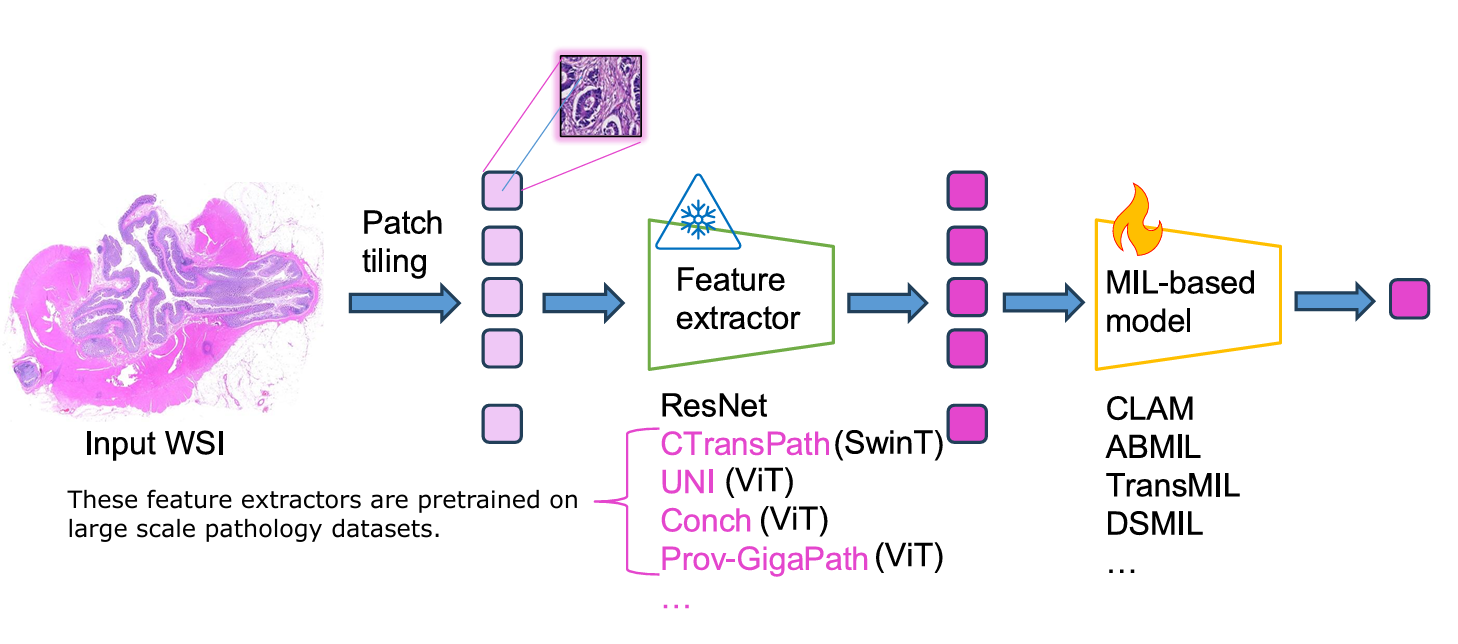

Note: Fix line 139 in `create_patches_fp.py`:
```
full_path = os.path.join(slide)
```

In [ ]:
# The coordinates of the patches are saved, you can change the path to any directory you want.
save_dir="./downloaded_data/TCGA-BRCA_patches"
# The directory where the WSI files are stored, you can change it to any directory you want.
wsi_dir="./downloaded_data/TCGA-BRCA"
# The WSI format, you can set it based on the format of your WSI
wsi_format="svs" # .tiff, .svs
# The log file name, you can change it to any name you want.
log_name="BRCA.log"

# Normally, you don't need to change following lines.
# to set the patch size, please set it at `configs/resolution.py`
# 0: 40x, 1: 10x, 2: 5x, 4: 2.5x
!python create_patches_fp.py \
        --source $wsi_dir \
        --save_dir $save_dir --preset tcga.csv \
        --patch_level 1 \
        --wsi_format $wsi_format \
        --seg \
        --patch \
        --stitch

### 2.2. Extract features (use vision encoder of TITAN (CONCHv1.5))

In [ ]:
!mkdir scripts/extract_feature/logs

In [ ]:
# Tải checkpoint của CONCHv1.5 (TITAN vision encoder)
!mkdir /content/PrePATH/models/ckpts
%cd /content/PrePATH/models/ckpts
!gdown --id 1QmH-dZJ6lr540XGAdZA5-IjkUv8ITHST
!mv "conch_v1_5_pytorch_model.bin" "conch1.5.bin"

In [ ]:
%cd /content/PrePATH
!mkdir csv

TASK_NAME="BRCA_feats_conch15"   # Task name, change it as you want

csv_path="csv/" + TASK_NAME
!mkdir $csv_path

# auto generate csv
!python scripts/extract_feature/generate_csv.py \
        --h5_dir "./downloaded_data/TCGA-BRCA_patches/patches" \
        --num 1 \
        --root "csv/BRCA_feats_conch15"

!python extract_features_fp_fast.py \
        --model "conch15" \
        --csv_path "./csv/BRCA_feats_conch15/part_0.csv" \
        --data_coors_dir "./downloaded_data/TCGA-BRCA_patches" \
        --data_slide_dir "./downloaded_data/TCGA-BRCA" \
        --feat_dir "./downloaded_data/TCGA-BRCA_feats_conch15" \
        --ignore_partial yes \
        --batch_size 32 \
        --datatype auto \
        --slide_ext ".svs" \
        --save_storage "yes"